In [23]:
# Basic imports and settings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Optional: reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training samples:", x_train.shape)
print("Testing samples:", x_test.shape)
print("Original dtype:", x_train.dtype)

Training samples: (60000, 28, 28)
Testing samples: (10000, 28, 28)
Original dtype: uint8


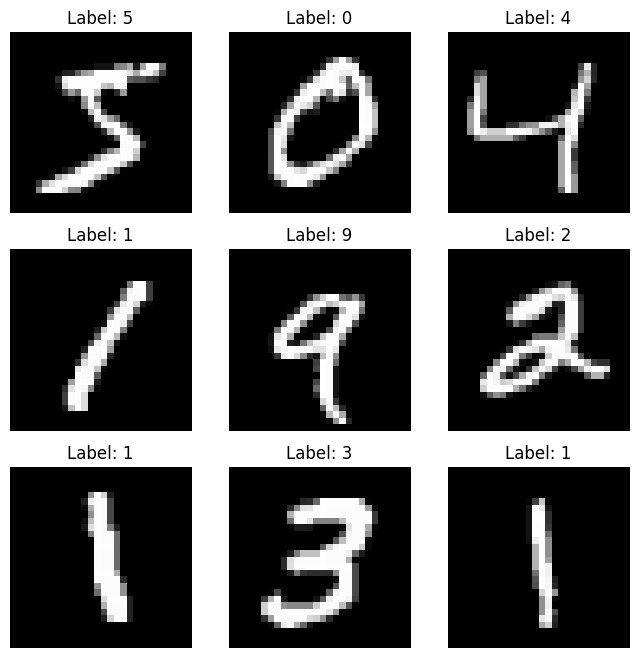

In [3]:
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

In [4]:
# Normalize and reshape for CNN
x_train = x_train.reshape(-1,28,28,1).astype("float32") / 255.0
x_test = x_test.reshape(-1,28,28,1).astype("float32") / 255.0

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("Data type:", x_train.dtype)

x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)
Data type: float32


In [5]:
inputs = keras.Input(shape=(28,28,1))

x = layers.Conv2D(32, (3,3), activation='relu', name='conv1')(inputs)
x = layers.MaxPooling2D((2,2), name='pool1')(x)
x = layers.Conv2D(64, (3,3), activation='relu', name='conv2')(x)
x = layers.MaxPooling2D((2,2), name='pool2')(x)
x = layers.Flatten(name='flatten')(x)
x = layers.Dense(64, activation='relu', name='dense1')(x)
outputs = layers.Dense(10, activation='softmax', name='output')(x)

model_cnn = Model(inputs=inputs, outputs=outputs)

model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model_cnn.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=3,  # increase to 10+ for better accuracy
    batch_size=64
)

Epoch 1/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 94s 104ms/step - accuracy: 0.9447 - loss: 0.1881 - val_accuracy: 0.9780 - val_loss: 0.0735
Epoch 2/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 63s 75ms/step - accuracy: 0.9818 - loss: 0.0590 - val_accuracy: 0.9842 - val_loss: 0.0562
Epoch 3/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 67s 79ms/step - accuracy: 0.9874 - loss: 0.0410 - val_accuracy: 0.9852 - val_loss: 0.0501


In [7]:
test_loss, test_accuracy = model_cnn.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9843 - loss: 0.0454
Test Loss: 0.0454, Test Accuracy: 0.9843


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


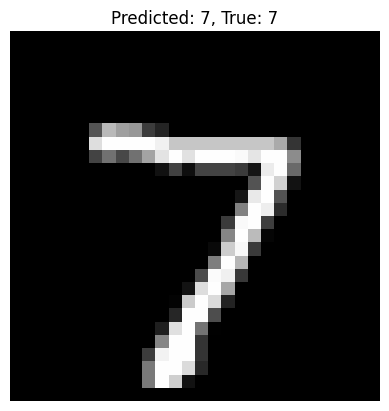

In [8]:
predictions = model_cnn.predict(x_test)
y_pred = np.argmax(predictions, axis=1)

# Show one prediction
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {y_pred[0]}, True: {y_test[0]}")
plt.axis('off')
plt.show()

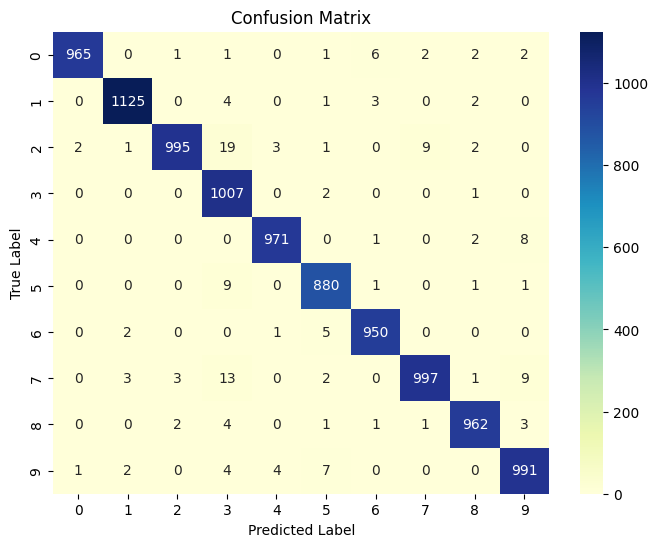

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.96      0.98      1032
           3       0.95      1.00      0.97      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.98       892
           6       0.99      0.99      0.99       958
           7       0.99      0.97      0.98      1028
           8       0.99      0.99      0.99       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

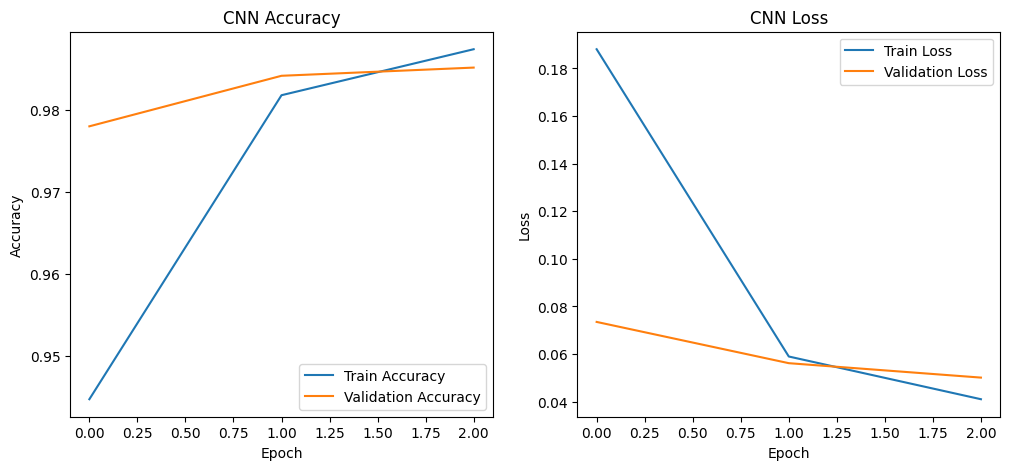

In [10]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

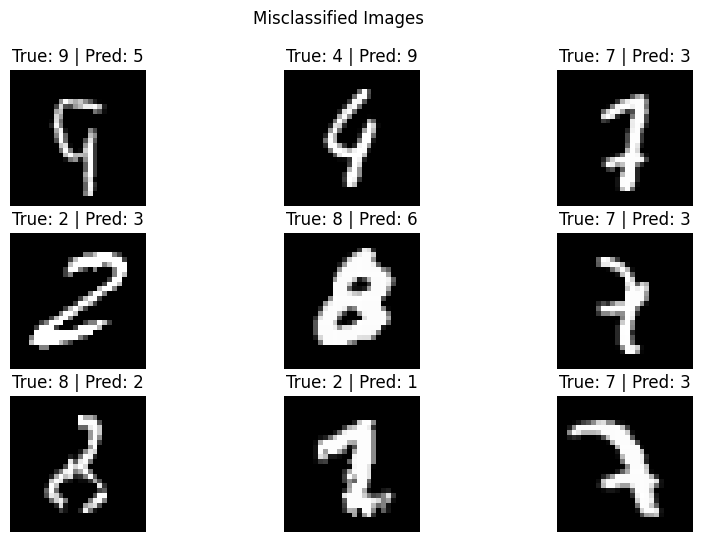

In [11]:
misclassified = np.where(y_test != y_pred)[0]

plt.figure(figsize=(10,6))
for i, idx in enumerate(misclassified[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"True: {y_test[idx]} | Pred: {y_pred[idx]}")
    plt.axis('off')
plt.suptitle("Misclassified Images")
plt.show()

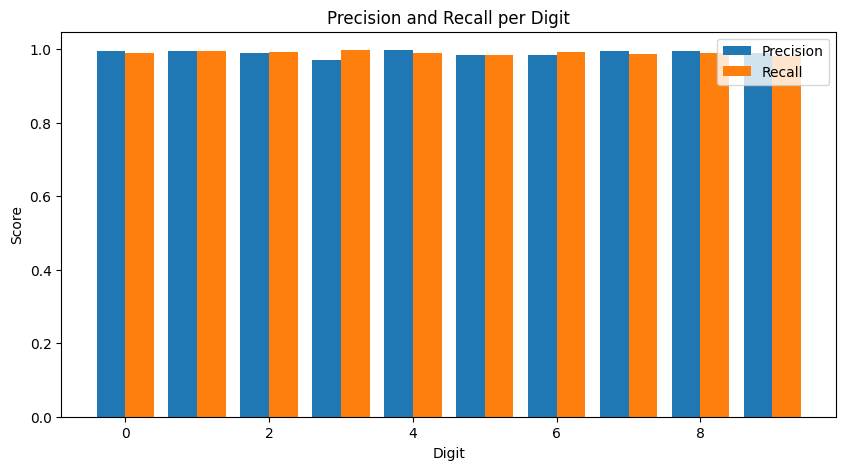

In [13]:
precision = precision_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)

digits = np.arange(10)

plt.figure(figsize=(10,5))
plt.bar(digits - 0.2, precision, width=0.4, label='Precision')
plt.bar(digits + 0.2, recall, width=0.4, label='Recall')
plt.xlabel("Digit")
plt.ylabel("Score")
plt.title("Precision and Recall per Digit")
plt.legend()
plt.show()

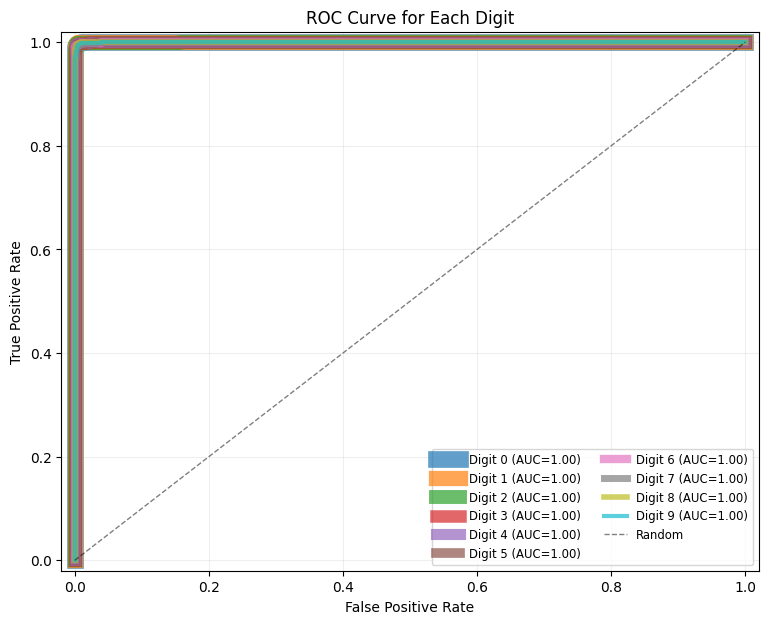

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# y_test: true labels (0-9)
# predictions: predicted probabilities from your model, shape (num_samples, 10)

# Convert test labels to one-hot encoding
y_test_bin = label_binarize(y_test, classes=np.arange(10))

# Ensure y_score is probabilities, shape: (num_samples, 10)
y_score = predictions  

# Use the new Matplotlib colormap method
colors = plt.colormaps['tab10']  # 10 distinct colors

plt.figure(figsize=(9, 7))

for i in range(10):
    # Compute ROC curve and AUC for each class
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    
    lw = 12 - i  # line width decreases for variety
    plt.plot(fpr, tpr, color=colors(i), lw=lw, alpha=0.7,
             label=f"Digit {i} (AUC={roc_auc:.2f})")

# Plot random chance line
plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')

plt.title("ROC Curve for Each Digit")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.legend(loc="lower right", ncol=2, fontsize='small')
plt.grid(alpha=0.2)
plt.show()

In [13]:
model_cnn.save("mnist_cnn_model.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


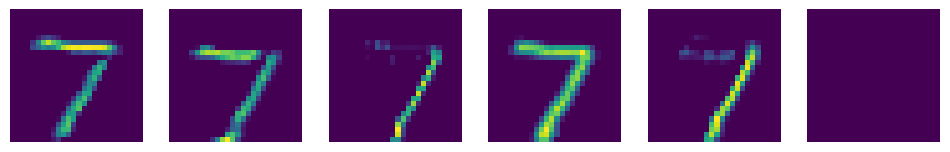

In [15]:
layer_outputs = [layer.output for layer in model_cnn.layers if 'conv' in layer.name]
activation_model = Model(inputs=model_cnn.input, outputs=layer_outputs)
activations = activation_model.predict(x_test[:1])

first_layer_activation = activations[0]
plt.figure(figsize=(12,6))
for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(first_layer_activation[0,:,:,i], cmap='viridis')
    plt.axis('off')
plt.show()

In [17]:
top_k_acc = tf.keras.metrics.top_k_categorical_accuracy(
    label_binarize(y_test, classes=np.arange(10)), predictions, k=3
)
print("Top-3 Accuracy:", np.mean(top_k_acc))

Top-3 Accuracy: 0.999


In [18]:
noise = np.random.normal(0, 0.2, x_test.shape)
x_test_noisy = np.clip(x_test + noise, 0, 1)
noisy_acc = model_cnn.evaluate(x_test_noisy, y_test)[1]
print(f"Accuracy on Noisy Images: {noisy_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9782 - loss: 0.0707
Accuracy on Noisy Images: 0.9782


In [19]:
idx = 123
top3 = np.argsort(predictions[idx])[-3:][::-1]
print(f"True label: {y_test[idx]}")
for i in top3:
    print(f"Digit {i}: {predictions[idx][i]*100:.2f}%")

True label: 6
Digit 6: 100.00%
Digit 8: 0.00%
Digit 5: 0.00%


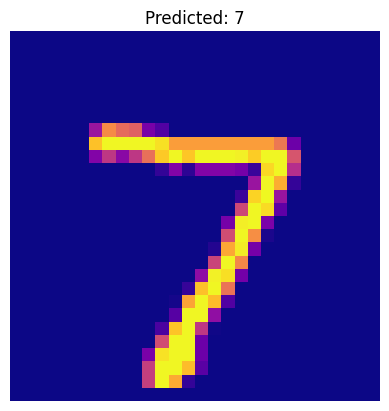

In [21]:
plt.imshow(x_test[0].reshape(28,28), cmap='plasma')
plt.title(f"Predicted: {y_pred[0]}")
plt.axis('off')
plt.show()